<html>
<div style="
background:linear-gradient(135deg, #1b1d01, #081d85);
padding:35px;
border-radius:15px;
color:white;
margin-bottom:35px;
">

<h2 style="margin:0;">
APOE Comparative Genomics and Protein Characterization 
</h2>

<p style="margin-top:12px;font-size:17px;">
Bioinformatics & Computational Biology Project
</p>

<p style="margin-top:20px;
        font-size:16px;
        opacity:.9;">
Sahel Sepehri • June - July 2026
</p>

</div>
</html>

<div style="
background: #e7e9ea;
border-left:6px solid  #2693e1;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h2 style="margin:0;color: #0F172A;">
Introduction
</h2>

</div>


Questions

  

- What is APOE?
- where is it located ?
- What is its biological function?
- Why is it important in human health?
- Why is bioinformatics useful for studying APOE?
- Why is it commonly studied?
-  what protein does it encode?
- What will this project analyze?

APOE (Apolipoprotein E) is involved in lipid transport and is strongly associated with Alzheimer's disease.

Steps in this notebook:
1. Get gene information manually from NCBI
2. Download FASTA sequence
3. Analyze sequence (length, GC%, Nucleotides Frequency)
4. Transcribe (DNA to RNA) and translate (RNA to Protein)
5. Analyze protein properties


---

<div style="
background: #e7e9ea;
border-left:6px solid  #2693e1;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h2 style="margin:0;color: #0F172A;">
Import Required Libraries
</h2>

</div>


In [ ]:
import pandas as pd

import matplotlib.pyplot as plt

from Bio import Entrez                      # Entrez can actually handles messages (communication) between our computer and the NCBI database.

from Bio import SeqIO                       # SeqIO reads and writes biological sequence file formats like FASTA.

from Bio.SeqUtils import ProtParam          # ProtParam analyzes protein properties (like MW, pI, instability)

from Bio.SeqUtils.ProtParam import ProteinAnalysis

from collections import Counter
 
Entrez.email = "sahelsepehri99@gmail.com"   # We sould tell NCBI who we are so we won't get blocked.


---

<div style="
background: #e7e9ea;
border-left:6px solid  #2693e1;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h2 style="margin:0;color: #0F172A;">
Biological and Database Exploration of APOE
</h2>

</div>


`Retrieving APOE Gene Information from NCBI`

The APOE gene was first explored using the NCBI Gene database to obtain reliable genomic and functional information. The [NCBI - APOE Page](https://www.ncbi.nlm.nih.gov/gene/?term=APOE) provides a comprehensive overview of the gene, including its official nomenclature, genomic location, gene structure, and links to related biological resources.

Two screenshots are included to illustrate the APOE gene summary page and its genomic location on chromosome 19 together with neighboring genes.

To organize the retrieved information, a Python dictionary was created containing key gene identifiers and characteristics. The dictionary was then converted into a pandas DataFrame to generate a clean and readable summary table.


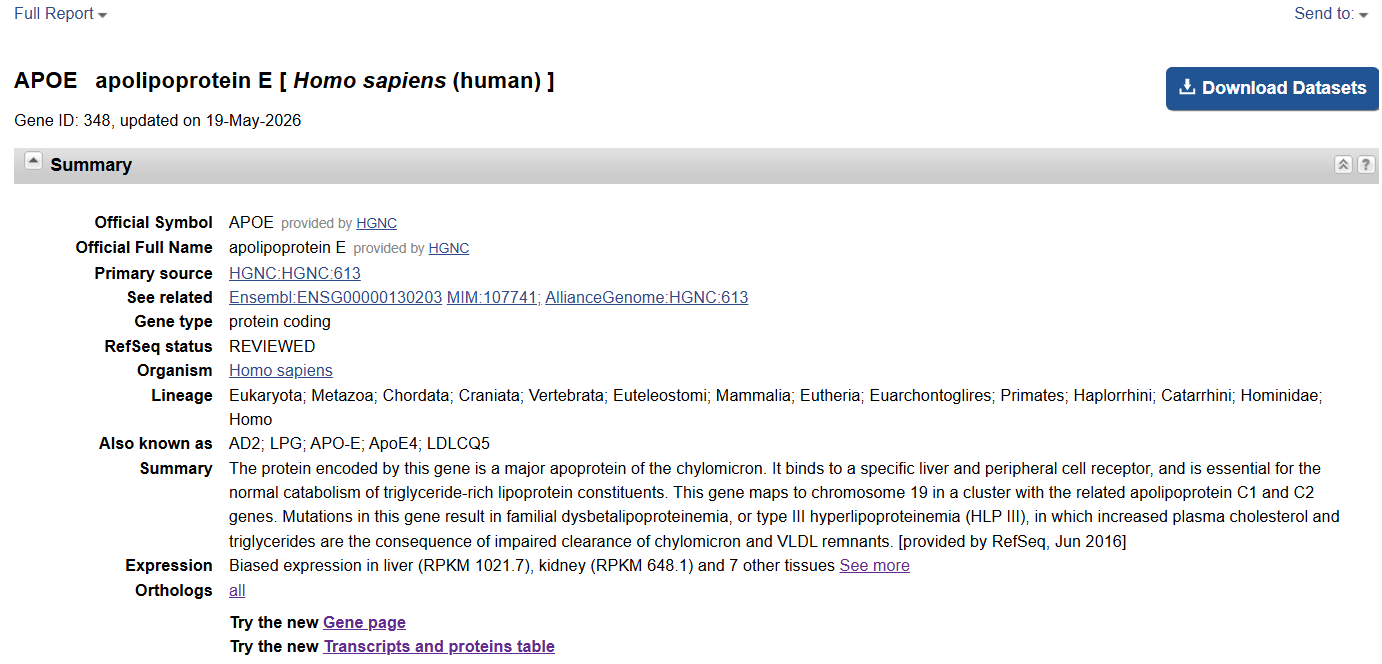

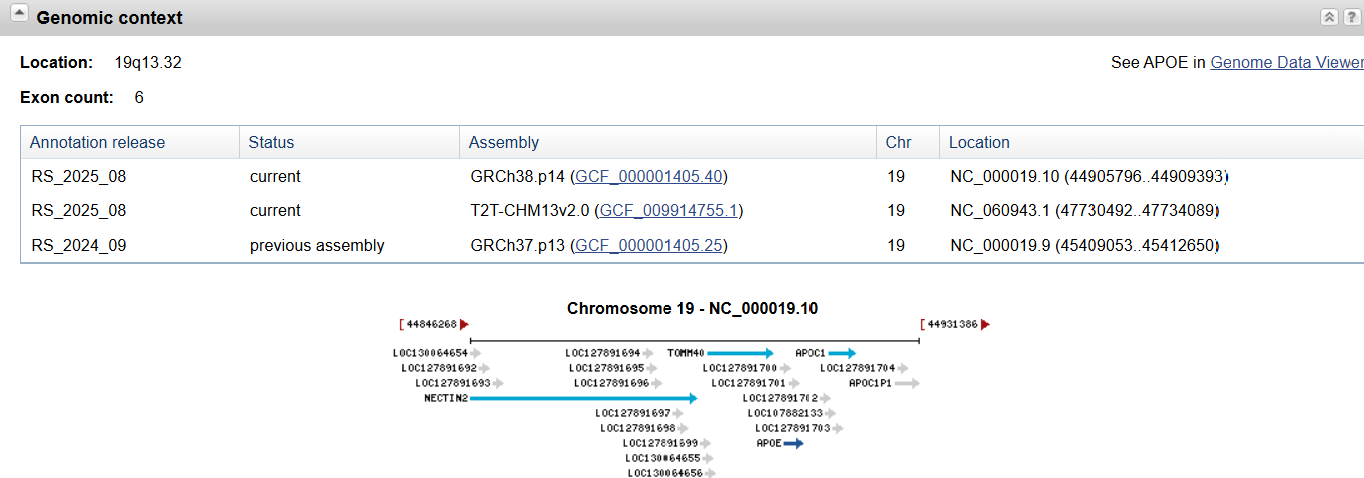

In [ ]:
apoe_human_info = {
    "Gene Symbol" : "APOE",
    "Official Full Name" : "apolipoprotein E",
    "NCBI Gene ID" : "348",
    "Gene type" : "protein coding",
    "Ensembl ID" : "ENSG00000130203",
    "HGNC ID" : "HGNC:613",
    "Other Names" : "AD2, LPG, APO-E, ApoE4, LDLCQ5",
    "Organism" : "Homo sapiens",
    "Protein Isoforms" : "5",
    "Transcripts Counts" : "5",
    "Chromosome": "19",
    "Location": "19q13.32",
    "Exon count": "6",
    "Intron count" : "5"  #Exon - 1
}


df = pd.DataFrame(list(apoe_human_info.items()), columns= ["Identifier Type", "Value"])

df.style


---

<div style="
background: #e7e9ea;
border-left:6px solid  #2693e1;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h2 style="margin:0;color: #0F172A;">
Retrieving APOE Gene Information Programmatically Using Biopython
</h2>

</div>





> After manually exploring the APOE gene on the NCBI Gene website, the same information was retrieved programmatically using the Biopython `Entrez` module. Automating data retrieval improves reproducibility and allows gene information to be accessed directly from the NCBI database without manual searching.

> The analysis begins by using `Entrez.esearch()` to search the NCBI Gene database for the human **APOE** gene and obtain its unique Gene ID. This identifier is then passed to `Entrez.esummary()`, which retrieves a structured summary containing essential gene annotations.

> Finally, the extracted information, including the gene name, description, chromosome, genomic location, and aliases, is organized into a pandas DataFrame to create a concise and readable summary table for downstream analyses.


### Gene ID

In [ ]:
# Search the NCBI Gene database for the human APOE gene
search_handle = Entrez.esearch(
    db="gene",
    term="APOE[Gene] AND Homo sapiens[Organism]"
)

# Read the search results and extract the Gene ID
search_record = Entrez.read(search_handle)
gene_id = search_record["IdList"][0]

print(f"APOE Gene ID: {gene_id}")


### Gene Summary

In [ ]:
# Retrieve the gene summary using the Gene ID
handle = Entrez.esummary(
    db="gene",
    id=gene_id,
    retmode="xml"
)

summary = Entrez.read(handle)

# Extract the first document summary
doc = summary["DocumentSummarySet"]["DocumentSummary"][0]

# Store selected annotations in a dictionary
data = {
    "Gene Name": doc["Name"],
    "Description": doc["Description"],
    "Chromosome": doc["Chromosome"],
    "Map Location": doc["MapLocation"],
    "Aliases": doc["OtherAliases"]
}

# Convert the dictionary into a DataFrame
df = pd.DataFrame([data])

# Display the table
df

---

<div style="
background: #e7e9ea;
border-left:6px solid  #2693e1;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h2 style="margin:0;color: #0F172A;">
APOE mRNA Sequence Retrieval and Nucleotide Analysis
</h2>

</div>

### > Programmatic Retrieval of APOE mRNA Sequence

> The human **APOE mRNA sequence** was retrieved programmatically from the NCBI Nucleotide database using **Biopython**.
> The RefSeq accession **`NM_000041.4`** was used as the reference APOE transcript.
> The sequence was obtained using `Entrez.efetch()` and parsed with the `SeqIO` module for downstream analysis.
> 
> The first 100 nucleotides were displayed as an initial quality check.
> 
> Although NM_000041.4 represents an mRNA transcript, RefSeq nucleotide records are stored using the DNA alphabet (T instead of U). The sequence was converted into RNA notation using transcription when required.

In [ ]:
# Entrez.efetch() and SeqIO parsing code
# Retrieve the reference APOE mRNA sequence from the NCBI Nucleotide database

# Fetch means "to go and get something or someone and bring them back"
# We ask NCBI to fetch a specific mRNA ID and save the connection handle
# id="NM_000041.4" -> is the RefSeq accession of the human APOE mRNA transcript
# rettype="fasta" -> returns the nucleotide sequence in FASTA format.
# retmode = "text" -> returns a simple text format (FASTA) instead of XML 

handle = Entrez.efetch(
    db="nucleotide",
    id="NM_000041.4",
    rettype="fasta",
    retmode="text"
)

# Read the FASTA record using SeqIO
mrna_record = SeqIO.read(handle, "fasta")
handle.close()

# Extract the nucleotide sequence
mrna_seq = mrna_record.seq

# Display sequence description
print(mrna_record.description)

# Display the first 100 nucleotides
print("\nFirst 100 nucleotides:")
print("- Reference nucleotide sequence (DNA notation, T):")
print(mrna_seq[:100])



# Convert the DNA-style nucleotide sequence (T) into an RNA sequence (U)
rna_seq = mrna_seq.transcribe()


print("\n- RNA sequence after transcription (U):")
print(rna_seq[:100])

### > Nucleotide Composition and GC Content Analysis

> **Objective:**
> To characterize the `nucleotide composition` and calculate the `GC content` of the APOE transcript.
> 
>**Method:**
> The frequency of each nucleotide (**`A, C, G, and T`**) was calculated, and GC content was determined as the `percentage of guanine and cytosine nucleotides` within the sequence.


In [ ]:
# Nucleotide counting and GC content calculation code

# Convert sequence to uppercase
sequence = str(mrna_record.seq).upper()

# Sequence length
total = len(sequence)

# Count nucleotides
a_count = sequence.count("A")
c_count = sequence.count("C")
g_count = sequence.count("G")
t_count = sequence.count("T")

# Calculate GC content
gc_content = (g_count + c_count) / total * 100

# Create DataFrame
df_nt = pd.DataFrame({
    "Nucleotide": ["A", "C", "G", "T"],
    "Count": [a_count, c_count, g_count, t_count],
    "Percentage (%)": [
        round(a_count / total * 100, 2),
        round(c_count / total * 100, 2),
        round(g_count / total * 100, 2),
        round(t_count / total * 100, 2)
    ]
})

# Display results
print(f"Sequence Length: {total} nt")
print(f"GC Content: {gc_content:.2f}%\n")

df_nt

### > Results

>The APOE transcript contains:
>- **Sequence length:** 1166 nucleotides
>- **GC content:** 69.04%
> The nucleotide composition is summarized in the table above.

### > Interpretation

> - The nucleotide composition provides a basic characterization of the APOE transcript sequence.
> - The relatively high GC content indicates a `GC-rich sequence`, which may contribute to `increased nucleotide stability` due to stronger G–C base pairing.
> - This analysis represents an initial quality assessment before downstream analyses, including translation, protein characterization, and evolutionary comparison.

---

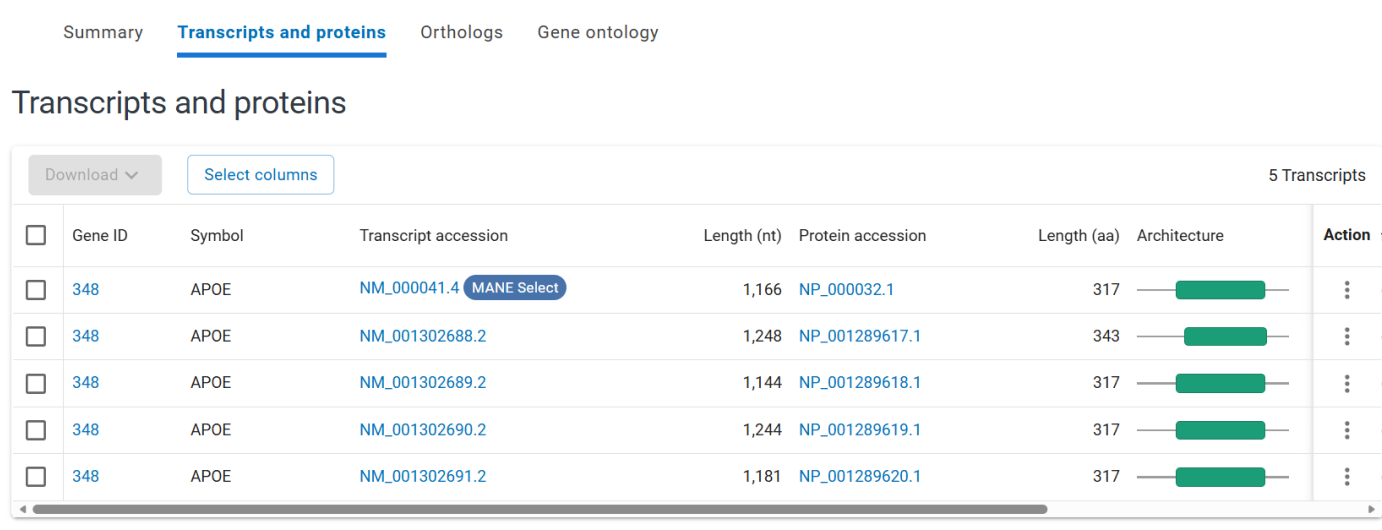

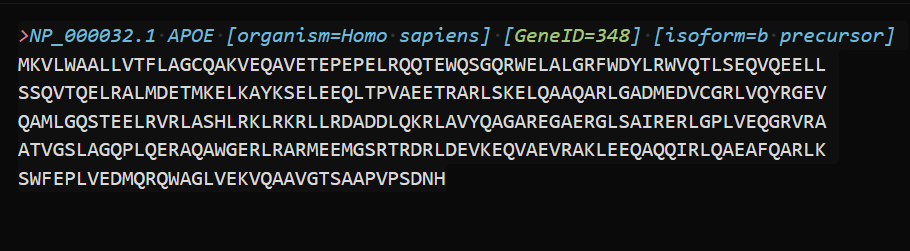

<div style="
background: #e7e9ea;
border-left:6px solid  #2693e1;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h2 style="margin:0;color: #0F172A;">
APOE Protein Sequence Retrieval and Characterization
</h2>

</div>

### > APOE Protein Information
> - The human APOE protein sequence was obtained from the NCBI Protein database using the RefSeq accession **`NP_000032.1`**.
> - NP_000032.1 corresponds to the **`apolipoprotein E isoform b precursor`**, encoded by transcript variant 2 (**NM_000041.4**).

| Feature    | Description                          |
| ---------- | ------------------------------------ |
| Protein    | apolipoprotein E isoform b precursor |
| RefSeq ID  | NP_000032.1                          |
| Length     | 317 amino acids                      |
| Organism   | Homo sapiens                         |
| Transcript | NM_000041.4                          |


### > Programmatic Retrieval of APOE Protein Sequence

> - The APOE protein sequence was retrieved programmatically from NCBI using `Biopython`.
> - The sequence was fetched using the RefSeq accession **`NP_000032.1`**, parsed using `SeqIO`, and saved in FASTA format for downstream analysis.

In [ ]:
handle = Entrez.efetch(             # Fetch APOE protein sequence from NCBI using its RefSeq ID
    db="protein",
    id="NP_000032.1",
    rettype="fasta",
    retmode="text"
    )

protein_record = SeqIO.read(handle, "fasta")    # Read the sequence and close connection
handle.close()

# Display sequence info
print(protein_record.description)
print("\nFirst 100 characters of FASTA:")
print(protein_record.seq[:100])
print("Protein length:", len(protein_record.seq), "a.a")


# Save to file
SeqIO.write(protein_record, "APOE_protein.fasta", "fasta")
print("\nSaved as APOE_protein.fasta")


### > Protein Physicochemical Analysis (ProtParam)

>**Objective:**
>To characterize the physicochemical properties of the human APOE protein based on its amino acid sequence.
>
>**Method:**
> The APOE amino acid sequence was analyzed using the **`ProtParam module in Biopython`**.
>
> The following properties were calculated:
>- Amino acid composition
>- Molecular weight
>- Theoretical isoelectric point (pI)
>- Instability index
>- Aromaticity
>- GRAVY score (hydrophobicity)
>- Secondary structure fractions

In [ ]:
# APOE Protein Properties (ProtParam Analysis)
# Create a ProtParam object from the protein sequence
my_protein = ProtParam.ProteinAnalysis(str(protein_record.seq))

### > 1. Amino Acid Composition
> The frequency and percentage of each amino acid were calculated to describe the sequence composition of APOE.

In [ ]:
# Load the protein sequence
handle = Entrez.efetch(db="protein", id="NP_000032.1", rettype="fasta", retmode="text")
protein_record = SeqIO.read(handle, "fasta")
handle.close()

# Create ProtParam object for protein analysis
my_protein = ProtParam.ProteinAnalysis(str(protein_record.seq))

# Count amino acid frequencies
sequence = str(protein_record.seq)
aa_counts = Counter(sequence)
total_aa = sum(aa_counts.values())

# Amino acid dictionary: 1-letter code → (Full Name, 3-letter code)
aa_names = {
    'A': ('Alanine', 'Ala'), 'R': ('Arginine', 'Arg'), 'N': ('Asparagine', 'Asn'),
    'D': ('Aspartic Acid', 'Asp'), 'C': ('Cysteine', 'Cys'), 'Q': ('Glutamine', 'Gln'),
    'E': ('Glutamic Acid', 'Glu'), 'G': ('Glycine', 'Gly'), 'H': ('Histidine', 'His'),
    'I': ('Isoleucine', 'Ile'), 'L': ('Leucine', 'Leu'), 'K': ('Lysine', 'Lys'),
    'M': ('Methionine', 'Met'), 'F': ('Phenylalanine', 'Phe'), 'P': ('Proline', 'Pro'),
    'S': ('Serine', 'Ser'), 'T': ('Threonine', 'Thr'), 'W': ('Tryptophan', 'Trp'),
    'Y': ('Tyrosine', 'Tyr'), 'V': ('Valine', 'Val')
}

# Build composition table
data = []
for aa, count in aa_counts.most_common():
    if aa in aa_names:
        full_name, three_letter = aa_names[aa]
        percentage = (count / total_aa) * 100
        data.append([aa, three_letter, full_name, count, round(percentage, 2)])
        
        
        
# Display as DataFrame
# The table below summarizes the percentage of each amino acid in the APOE protein sequence.
df_aa = pd.DataFrame(data, columns=['1-Letter', '3-Letter', 'Name', 'Count', '%'])
print(df_aa)


Interpretation

> The amino acid composition provides a general overview of the APOE protein sequence and serves as the basis for subsequent physicochemical analyses.

---

### > 2. Molecular Weight 

In [ ]:
# Calculate the molecular weight of the APOE protein
mw = my_protein.molecular_weight()

print(f"Molecular weight: {mw:.2f} Da")

Interpretation:
>The predicted molecular weight of APOE is approximately **36.15 kDa**, which is consistent with the expected size of the mature human protein.

---

### > 3. Theoretical Isoelectric Point (pI)

In [ ]:
# Calculate the theoretical isoelectric point (pI)
pi = my_protein.isoelectric_point()

print(f"Isoelectric point (pI): {pi:.2f}")

Interpretation

> The theoretical pI of **`5.65`** indicates that APOE is expected to carry a `net negative charge` under physiological conditions, which may influence its interactions with lipids and receptors.

---

### > 4. Instability index 

In [ ]:
#Instability index (below 40 = stable, above 40 = unstable)
instability = my_protein.instability_index()
print(f"Instability index: {instability:.2f}")
if instability < 40:
    print("Protein is predicted to be Stable.")
else:
    print("Protein is predicted to be Unstable.")

Interpretation

> The predicted instability index (**`44.88`**) is slightly above the ProtParam stability threshold, suggesting potential `instability` based solely on amino acid composition. This computational prediction does not necessarily reflect protein stability under physiological conditions.

---

### > 5. Aromaticity

In [ ]:
# Calculate the aromaticity of the APOE protein
aromaticity = my_protein.aromaticity()


print(f"Aromaticity: {aromaticity:.2f}")

Interpretation

> The aromaticity value (**`0.05`**) indicates that `aromatic amino acids constitute a relatively small proportion of the APOE protein sequence.

---

### > 6. GRAVY (Grand Average of Hydropathy)


In [ ]:
# Calculate the GRAVY score
gravy = my_protein.gravy()


print(f"GRAVY (hydrophobicity): {gravy:.2f}")

if gravy > 0:
    print("Hydrophobic protein")
else:
    print("Hydrophilic protein")

Interpretation

> The negative GRAVY score (**`−0.60`**) indicates that APOE is `predominantly hydrophilic`, which is consistent with its function as a soluble plasma apolipoprotein involved in lipid transport.

---

### > 7. Secondary Structure Fraction

In [ ]:
sec_structure = my_protein.secondary_structure_fraction ()
print(f"Helix fraction: {sec_structure[0]:.3f} ({sec_structure[0]*100:.1f}%)")
print(f"Turn fraction:  {sec_structure[1]:.3f} ({sec_structure[1]*100:.1f}%)")
print(f"Sheet fraction: {sec_structure[2]:.3f} ({sec_structure[2]*100:.1f}%)")


Interpretation

> ProtParam predicts that APOE contains a high proportion of **`α-helices`** together with moderate **`β-sheet`** content.
> These values provide a general description of structural composition based on amino acid sequence and should not be interpreted as an experimentally determined three-dimensional structure.

---

### > Protein Characterization Summary

In [ ]:
sequence = str(protein_record.seq)
my_protein = ProteinAnalysis(sequence)

# Compute properties
mw = my_protein.molecular_weight()
pI = my_protein.isoelectric_point()
gravy = my_protein.gravy()
instability = my_protein.instability_index()
aromaticity = my_protein.aromaticity()
helix, turn, sheet = my_protein.secondary_structure_fraction()

# Build final table
data = [
    ["Molecular Weight (Da)", mw],
    ["Isoelectric Point (pI)", pI],
    ["GRAVY (Hydrophobicity)", gravy],
    ["Instability Index", instability],
    ["Aromaticity", aromaticity],
    ["Helix Fraction", helix],
    ["Turn Fraction", turn],
    ["Sheet Fraction", sheet]
]

# Create summary table of ProtParam results
df = pd.DataFrame(data, columns=["Property", "Value"])

# Round numerical values
df["Value"] = df["Value"].round(2)
# Display table
display(df)

### Overall Interpretation

> ProtParam analysis indicates that APOE is a `predominantly hydrophilic protein with a slightly acidic isoelectric point and a mainly α-helical structure. Although the instability index is slightly above the ProtParam threshold, this prediction is sequence-based and does not necessarily represent protein behavior in vivo.
> Overall, these results provide a computational characterization of the APOE protein that is consistent with its known biological role in lipid transport and receptor-mediated metabolism.

---

<div style="
background: #e7e9ea;
border-left:6px solid  #2693e1;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h2 style="margin:0;color: #0F172A;">
Clinical Variant Analysis (ClinVar)
</h2>

</div>

Introduction

ClinVar is a publicly available database maintained by the NCBI that provides information on the relationships between human genetic variants and clinical phenotypes.

In this section, ClinVar was used to investigate clinically relevant variants reported for the APOE gene.

Objective

To identify clinically relevant APOE variants and summarize their reported disease associations.

Method

The APOE gene was searched in the ClinVar database. Representative pathogenic and risk-associated variants were reviewed together with their reported clinical significance.

| Variant  | Protein Change | Clinical Significance | Associated Condition           |
| -------- | -------------- | --------------------- | ------------------------------ |
| rs429358 | p.Cys130Arg    | Risk factor           | Late-onset Alzheimer's disease |
| rs7412   | p.Arg176Cys    | Risk factor           | Late-onset Alzheimer's disease |



| Variant  | Protein Change | Clinical Significance | Associated Condition                   |
| -------- | -------------- | --------------------- | -------------------------------------- |
| c.388T>C | p.Cys130Arg    | Pathogenic            | Familial type III hyperlipoproteinemia |
| c.526C>T | p.Arg176Cys    | Pathogenic            | Familial type III hyperlipoproteinemia |
| c.548G>C | p.Gly183Ala    | Likely pathogenic     | Familial type III hyperlipoproteinemia |
| c.526C>T | p.Arg176Cys    | Drug response         | Atorvastatin response                  |


### Interpretation

ClinVar analysis identified several clinically relevant APOE variants associated with lipid metabolism disorders and Alzheimer's disease susceptibility.

The variants **rs429358** and **rs7412** define the major APOE isoforms (**ε2, ε3, and ε4**), which are well-established genetic determinants of Alzheimer's disease risk.

Several pathogenic variants were also associated with **familial type III hyperlipoproteinemia**, highlighting the important role of APOE in lipid metabolism. In addition, one variant was reported to influence the response to atorvastatin, demonstrating the pharmacogenomic relevance of APOE.

### Summary

Overall, ClinVar results demonstrate that APOE harbors multiple clinically significant variants associated with human disease, emphasizing the importance of this gene in both lipid metabolism and neurodegenerative disorders.


---

 <div style="
background: #e7e9ea;
border-left:6px solid  #2693e1;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h2 style="margin:0;color: #0F172A;">
Final Conclusion
</h2>

</div>

 <div style="
background: #e7e9ea;
border-left:6px solid  #2693e1;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h2 style="margin:0;color: #0F172A;">
Limitations
</h2>

</div>

 <div style="
background: #e7e9ea;
border-left:6px solid  #2693e1;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h2 style="margin:0;color: #0F172A;">
Future Work
</h2>

</div>


- Protein Domain Analysis

 <div style="
background: #e7e9ea;
border-left:6px solid  #2693e1;
padding:15px 20px;
border-radius:10px;
margin:40px 0 25px 0;
">

<h2 style="margin:0;color: #0F172A;">
References 
</h2>

</div>


- [NCBI](https://www.ncbi.nlm.nih.gov/)
- [Pandas Documentation](https://pandas.pydata.org/docs/index.html)
- [Accessing NCBI’s Entrez databases - biopython](https://biopython.org/docs/latest/Tutorial/chapter_entrez.html)
- [ClinVar](https://www.ncbi.nlm.nih.gov/clinvar/)
- [Analyzing protein sequences with the ProtParam module](https://biopython.org/wiki/ProtParam)
- https://medlineplus.gov/genetics/gene/apoe/
- MedlinePlus [Internet]. Bethesda (MD): National Library of Medicine (US); [updated Jun 24; cited 2020 Jul 1]. Available from: https://medlineplus.gov/.
- https://www.geneticlifehacks.com/alzheimers-and-apoe-type/
- [Hydrophobic and Hydrophilic Amino Acids](https://aapep.bocsci.com/resources/hydrophobic-and-hydrophilic-amino-acids.html)
- [BLASTp](https://blast.ncbi.nlm.nih.gov/Blast.cgi?PAGE=Proteins)